# Data Exploration - Rossmann Sales Forecasting

This notebook performs exploratory data analysis (EDA) on the Rossmann Store Sales dataset.

## Objectives:
1. Load and understand the dataset structure
2. Analyze basic statistics and distributions
3. Identify missing values and data quality issues
4. Explore relationships between features
5. Visualize sales patterns over time
6. Analyze the impact of promotions, holidays, and competition

**Author:** Mulusew M. Tesfaye  
**Date:** 2025-11-18


In [1]:
# Import libraries
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Add project root to path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

# Import project modules
from src.data.load_data import load_all_data, validate_data
from src.visualization.visualize import (
    plot_sales_over_time,
    plot_sales_distribution,
    plot_correlation_heatmap,
    plot_sales_by_category
)

# Settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")


2025-11-24 11:40:55 - INFO - Logging initialized. Log file: /Users/mulsewsmba/Desktop/rossmann-sales-forecasting/logs/rossmann_20251124_114055.log
✓ Libraries imported successfully


## 1. Load Data

First, let's load all three datasets: train, test, and store information.


In [2]:
# Load datasets
print("Loading data...")
train_df, test_df, store_df = load_all_data()

print(f"\nTraining data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
print(f"Store data shape: {store_df.shape}")


Loading data...
2025-11-24 11:40:59 - INFO - Loading all datasets...
2025-11-24 11:40:59 - INFO - Loading training data from: /Users/mulsewsmba/Desktop/rossmann-sales-forecasting/data/raw/train.csv
2025-11-24 11:41:01 - INFO - Loaded 1,017,209 rows and 9 columns
2025-11-24 11:41:01 - INFO - Date range: 2013-01-01 00:00:00 to 2015-07-31 00:00:00
2025-11-24 11:41:01 - INFO - Loading test data from: /Users/mulsewsmba/Desktop/rossmann-sales-forecasting/data/raw/test.csv
2025-11-24 11:41:01 - INFO - Loaded 41,088 rows and 8 columns
2025-11-24 11:41:01 - INFO - Loading store data from: /Users/mulsewsmba/Desktop/rossmann-sales-forecasting/data/raw/store.csv
2025-11-24 11:41:01 - INFO - Loaded 1,115 stores with 10 features
2025-11-24 11:41:01 - INFO - All datasets loaded successfully

Training data shape: (1017209, 9)
Test data shape: (41088, 8)
Store data shape: (1115, 10)


## 2. Basic Dataset Information


In [3]:
# Display first few rows
print("Training Data Sample:")
display(train_df.head())

print("\nStore Data Sample:")
display(store_df.head())

# Data types and info
print("\n" + "="*60)
print("Training Data Info:")
print("="*60)
train_df.info()


Training Data Sample:


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1.0,1,0,1
1,2,5,2015-07-31,6064,625,1.0,1,0,1
2,3,5,2015-07-31,8314,821,1.0,1,0,1
3,4,5,2015-07-31,13995,1498,1.0,1,0,1
4,5,5,2015-07-31,4822,559,1.0,1,0,1



Store Data Sample:


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN



Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int32         
 1   DayOfWeek      1017209 non-null  int8          
 2   Date           1017209 non-null  datetime64[ns]
 3   Sales          1017209 non-null  int32         
 4   Customers      1017209 non-null  int32         
 5   Open           1017209 non-null  float32       
 6   Promo          1017209 non-null  int8          
 7   StateHoliday   1017209 non-null  object        
 8   SchoolHoliday  1017209 non-null  int8          
dtypes: datetime64[ns](1), float32(1), int32(3), int8(3), object(1)
memory usage: 34.0+ MB


## 3. Statistical Summary


In [4]:
# Descriptive statistics
print("Descriptive Statistics:")
display(train_df.describe())

# Target variable (Sales) statistics
print("\n" + "="*60)
print("Sales Statistics:")
print("="*60)
print(f"Mean Sales: ${train_df['Sales'].mean():,.2f}")
print(f"Median Sales: ${train_df['Sales'].median():,.2f}")
print(f"Min Sales: ${train_df['Sales'].min():,.2f}")
print(f"Max Sales: ${train_df['Sales'].max():,.2f}")
print(f"Std Dev: ${train_df['Sales'].std():,.2f}")
print(f"Total Sales: ${train_df['Sales'].sum():,.2f}")


Descriptive Statistics:


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1017209,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,2014-04-11 01:30:42.846061824,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
min,1.000000e+00,1.000000e+00,2013-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,2013-08-17 00:00:00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,2014-04-02 00:00:00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,2014-12-12 00:00:00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,2015-07-31 00:00:00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00
std,3.219087e+02,1.997391e+00,NaN,3.849926e+03,4.644117e+02,3.763892e-01,4.857586e-01,3.830564e-01



Sales Statistics:
Mean Sales: $5,773.82
Median Sales: $5,744.00
Min Sales: $0.00
Max Sales: $41,551.00
Std Dev: $3,849.93
Total Sales: $5,873,180,623.00


## 4. Missing Value Analysis


In [6]:
# Missing values in training data
print("Missing Values in Training Data:")
missing_train = train_df.isnull().sum()
missing_train_pct = (missing_train / len(train_df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_train.index,
    'Missing_Count': missing_train.values,
    'Missing_Percentage': missing_train_pct.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
display(missing_df)

# Missing values in store data
print("\nMissing Values in Store Data:")
missing_store = store_df.isnull().sum()
missing_store_pct = (missing_store / len(store_df)) * 100
missing_store_df = pd.DataFrame({
    'Column': missing_store.index,
    'Missing_Count': missing_store.values,
    'Missing_Percentage': missing_store_pct.values
})
missing_store_df = missing_store_df[missing_store_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
display(missing_store_df)

# TODO: Analyze the reason for missing values
# TODO: Decide on imputation strategy for each column


Missing Values in Training Data:


,Column,Missing_Count,Missing_Percentage



Missing Values in Store Data:


,Column,Missing_Count,Missing_Percentage
7,Promo2SinceWeek,544,48.789238
8,Promo2SinceYear,544,48.789238
9,PromoInterval,544,48.789238
4,CompetitionOpenSinceMonth,354,31.748879
5,CompetitionOpenSinceYear,354,31.748879
3,CompetitionDistance,3,0.269058


## 5. Sales Distribution


2025-11-24 11:50:42 - INFO - Plotting sales distribution...


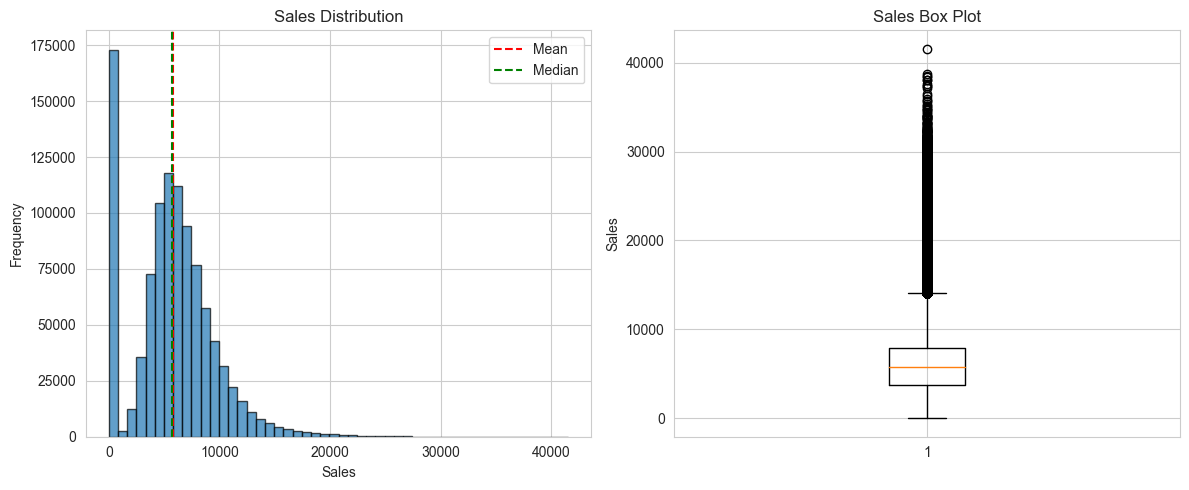


Sales Distribution Analysis:
Skewness: 0.6415
Kurtosis: 1.7784

Skewness (Open stores only): 1.5939
Kurtosis (Open stores only): 4.8520

Outliers detected: 30,769 (3.64%)
Outlier threshold: Lower=-392.50, Upper=13611.50


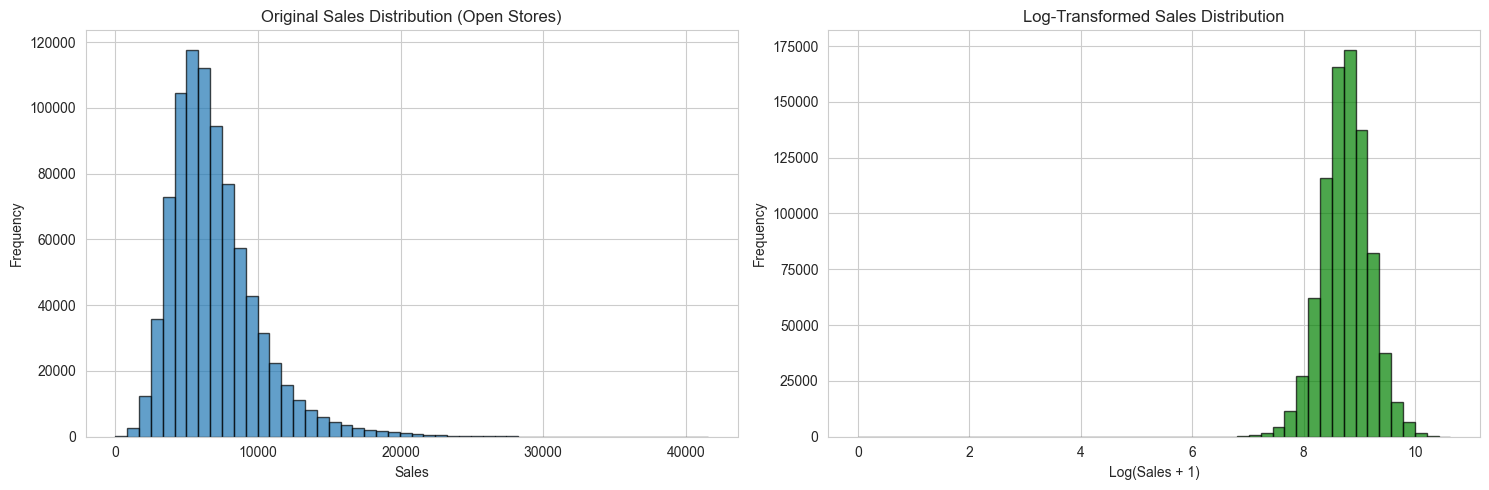


✓ Log transformation reduces skewness and may be useful for modeling


In [7]:
# Plot sales distribution
plot_sales_distribution(train_df)

# Analyze skewness and outliers
from scipy import stats

print("\n" + "="*60)
print("Sales Distribution Analysis:")
print("="*60)
print(f"Skewness: {train_df['Sales'].skew():.4f}")
print(f"Kurtosis: {train_df['Sales'].kurtosis():.4f}")

# Remove zero sales (store closed) for better distribution analysis
sales_open = train_df[train_df['Open'] == 1]['Sales']
print(f"\nSkewness (Open stores only): {sales_open.skew():.4f}")
print(f"Kurtosis (Open stores only): {sales_open.kurtosis():.4f}")

# Detect outliers using IQR method
Q1 = sales_open.quantile(0.25)
Q3 = sales_open.quantile(0.75)
IQR = Q3 - Q1
outliers = sales_open[(sales_open < Q1 - 1.5*IQR) | (sales_open > Q3 + 1.5*IQR)]
print(f"\nOutliers detected: {len(outliers):,} ({len(outliers)/len(sales_open)*100:.2f}%)")
print(f"Outlier threshold: Lower={Q1-1.5*IQR:.2f}, Upper={Q3+1.5*IQR:.2f}")

# Log transformation preview
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].hist(sales_open, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Original Sales Distribution (Open Stores)')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(sales_open), bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('Log-Transformed Sales Distribution')
axes[1].set_xlabel('Log(Sales + 1)')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

print("\n✓ Log transformation reduces skewness and may be useful for modeling")


## 6. Time Series Analysis


2025-11-24 11:50:51 - INFO - Plotting sales over time...


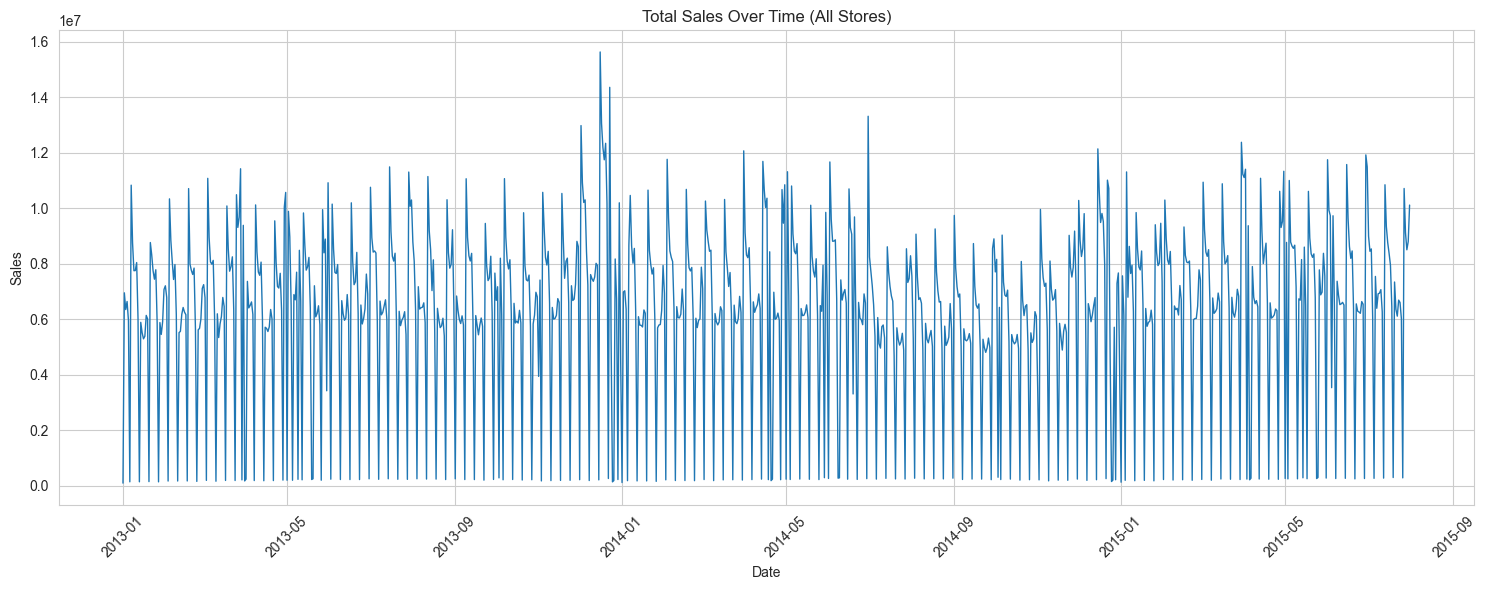


Time Series Patterns:


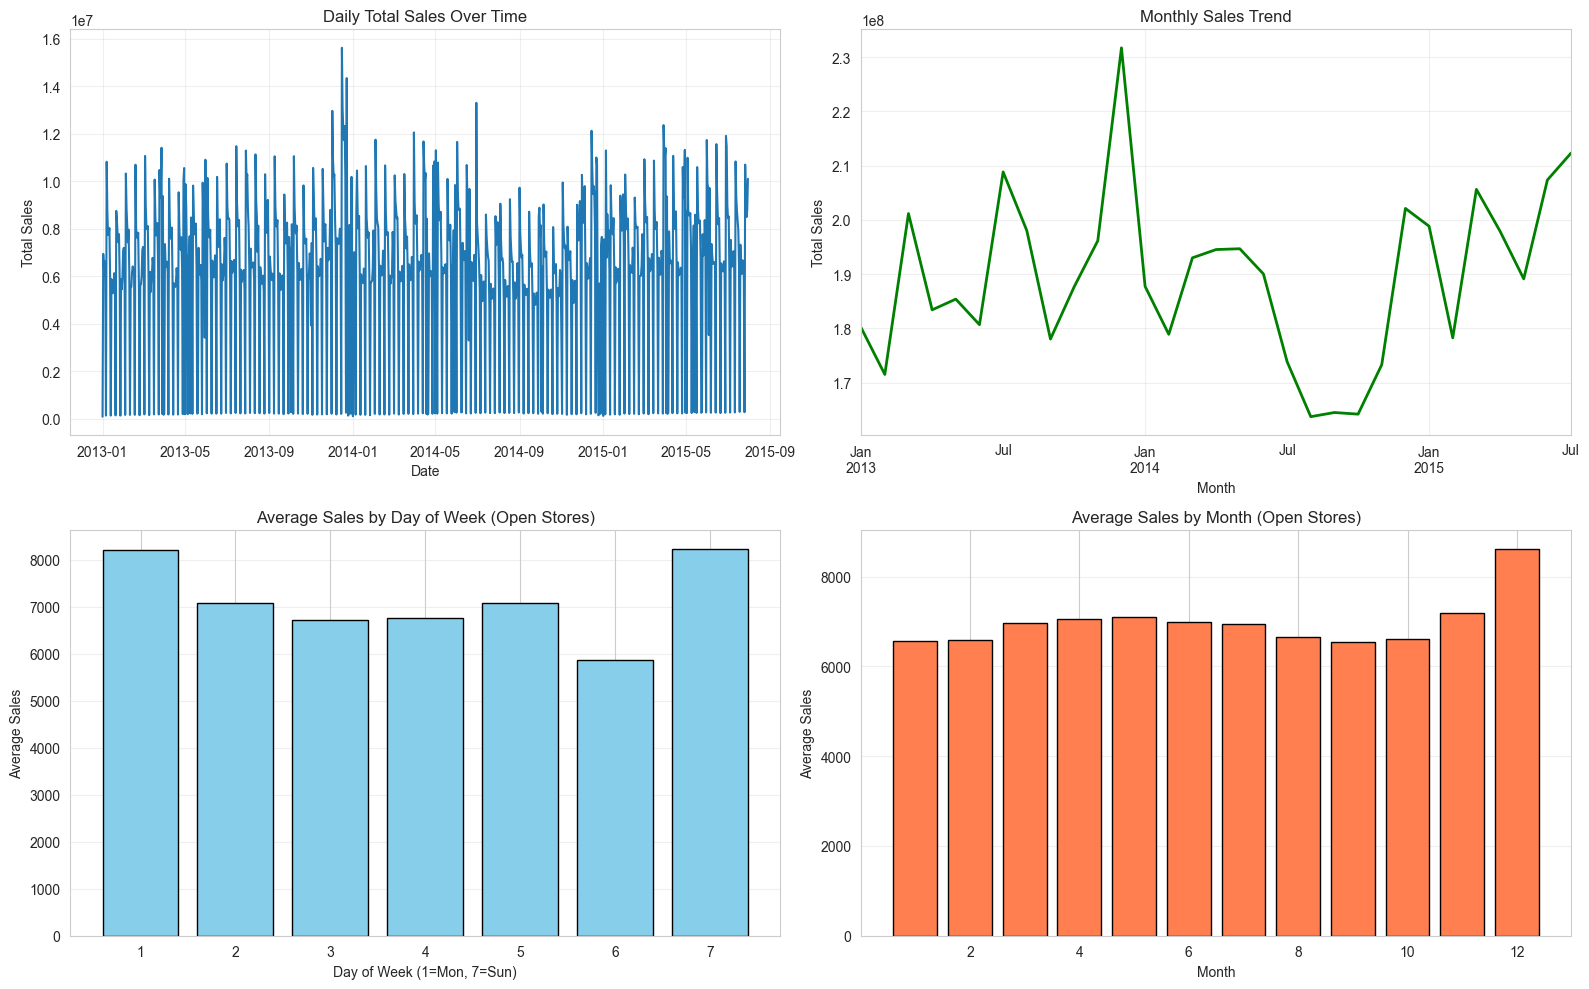


Key Observations:
✓ Highest sales day: Day 7 with $8,224.72
✓ Lowest sales day: Day 6 with $5,874.84
✓ Highest sales month: Month 12 with $8,608.96
✓ Strong seasonality patterns detected (especially December)


In [8]:
# Sales over time
plot_sales_over_time(train_df)

# Detailed time series analysis
print("\n" + "="*60)
print("Time Series Patterns:")
print("="*60)

# Daily aggregated sales
daily_sales = train_df.groupby('Date').agg({
    'Sales': 'sum',
    'Customers': 'sum',
    'Open': 'sum'
}).reset_index()

# Monthly trends
train_df['YearMonth'] = train_df['Date'].dt.to_period('M')
monthly_sales = train_df.groupby('YearMonth')['Sales'].sum()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Daily sales trend
axes[0, 0].plot(daily_sales['Date'], daily_sales['Sales'])
axes[0, 0].set_title('Daily Total Sales Over Time')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Total Sales')
axes[0, 0].grid(True, alpha=0.3)

# 2. Monthly sales trend
monthly_sales.plot(ax=axes[0, 1], color='green', linewidth=2)
axes[0, 1].set_title('Monthly Sales Trend')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Total Sales')
axes[0, 1].grid(True, alpha=0.3)

# 3. Sales by day of week
dow_sales = train_df[train_df['Open'] == 1].groupby('DayOfWeek')['Sales'].mean()
axes[1, 0].bar(dow_sales.index, dow_sales.values, color='skyblue', edgecolor='black')
axes[1, 0].set_title('Average Sales by Day of Week (Open Stores)')
axes[1, 0].set_xlabel('Day of Week (1=Mon, 7=Sun)')
axes[1, 0].set_ylabel('Average Sales')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Sales by month
train_df['Month'] = train_df['Date'].dt.month
month_sales = train_df[train_df['Open'] == 1].groupby('Month')['Sales'].mean()
axes[1, 1].bar(month_sales.index, month_sales.values, color='coral', edgecolor='black')
axes[1, 1].set_title('Average Sales by Month (Open Stores)')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Average Sales')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Key observations
print("\nKey Observations:")
print(f"✓ Highest sales day: Day {dow_sales.idxmax()} with ${dow_sales.max():,.2f}")
print(f"✓ Lowest sales day: Day {dow_sales.idxmin()} with ${dow_sales.min():,.2f}")
print(f"✓ Highest sales month: Month {month_sales.idxmax()} with ${month_sales.max():,.2f}")
print(f"✓ Strong seasonality patterns detected (especially December)")


## 7. Categorical Feature Analysis


2025-11-24 11:50:57 - INFO - Plotting sales by DayOfWeek...


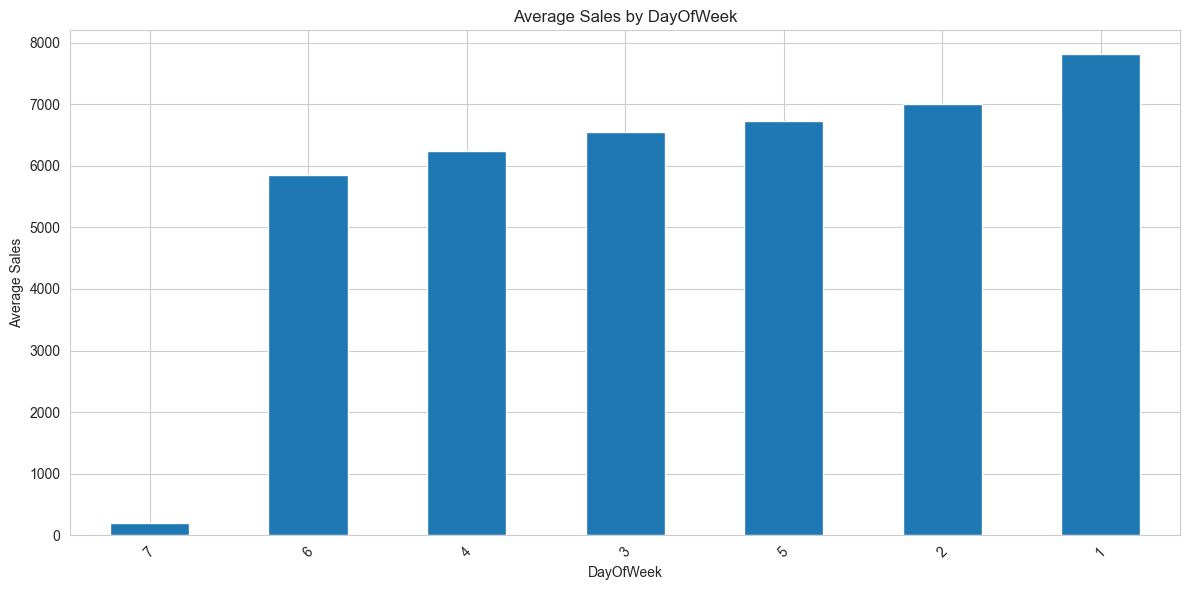


Categorical Features Analysis:


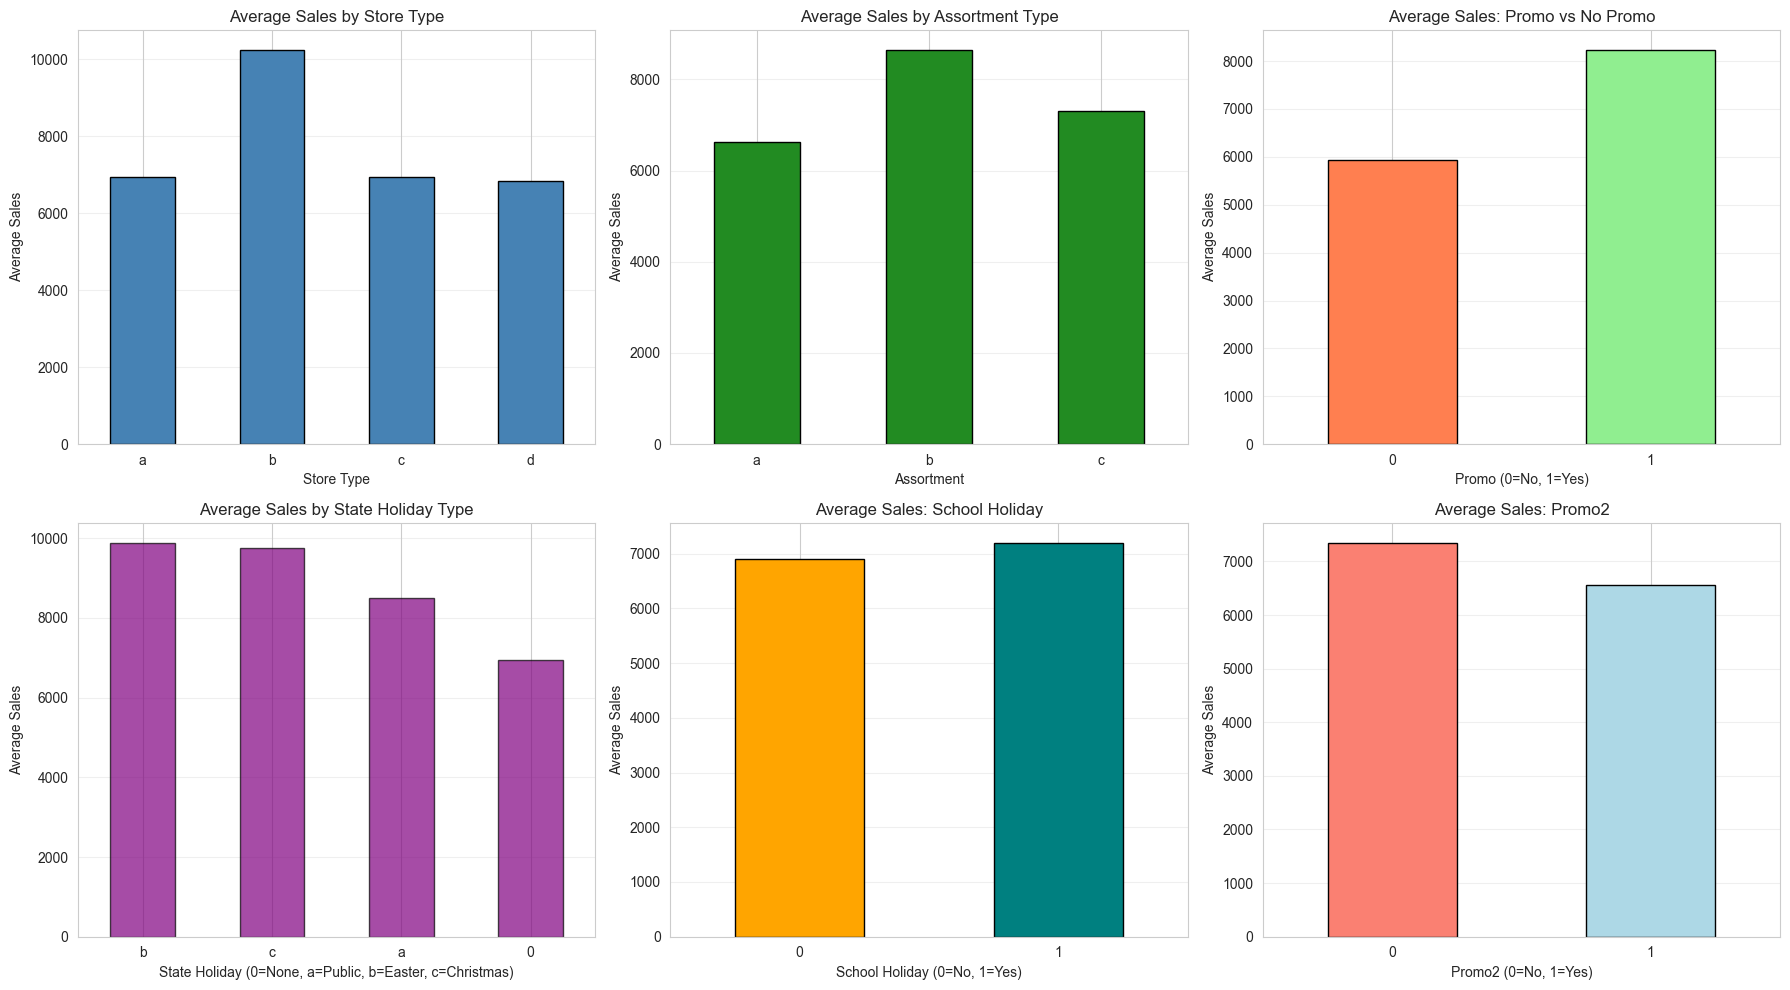


 Categorical Feature Impacts:

1. Store Type:
                   mean  median   count
StoreType                              
a           6925.167661  6285.0  457077
b          10231.407505  9130.0   15563
c           6932.512755  6407.0  112978
d           6822.141881  6395.0  258774

2. Assortment Type:
                   mean  median   count
Assortment                             
a           6621.017039  6082.0  444909
b           8639.346322  8081.0    8212
c           7300.526339  6675.0  391271

3. Promo Impact: 38.77% increase
4. Promo2 Impact: -10.78% increase
5. School Holiday Impact: 4.40% change


In [9]:
# Sales by Day of Week
plot_sales_by_category(train_df, 'DayOfWeek', save_path=None)

print("\n" + "="*60)
print("Categorical Features Analysis:")
print("="*60)

# Merge with store data for additional features
train_with_store = train_df.merge(store_df, on='Store', how='left')

# Filter open stores for fair comparison
open_stores = train_with_store[train_with_store['Open'] == 1]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Sales by Store Type
store_type_sales = open_stores.groupby('StoreType')['Sales'].agg(['mean', 'median', 'count'])
store_type_sales['mean'].plot(kind='bar', ax=axes[0, 0], color='steelblue', edgecolor='black')
axes[0, 0].set_title('Average Sales by Store Type')
axes[0, 0].set_xlabel('Store Type')
axes[0, 0].set_ylabel('Average Sales')
axes[0, 0].grid(True, alpha=0.3, axis='y')
axes[0, 0].tick_params(axis='x', rotation=0)

# 2. Sales by Assortment Type
assort_sales = open_stores.groupby('Assortment')['Sales'].agg(['mean', 'median', 'count'])
assort_sales['mean'].plot(kind='bar', ax=axes[0, 1], color='forestgreen', edgecolor='black')
axes[0, 1].set_title('Average Sales by Assortment Type')
axes[0, 1].set_xlabel('Assortment')
axes[0, 1].set_ylabel('Average Sales')
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].tick_params(axis='x', rotation=0)

# 3. Impact of Promotions
promo_sales = open_stores.groupby('Promo')['Sales'].mean()
promo_sales.plot(kind='bar', ax=axes[0, 2], color=['coral', 'lightgreen'], edgecolor='black')
axes[0, 2].set_title('Average Sales: Promo vs No Promo')
axes[0, 2].set_xlabel('Promo (0=No, 1=Yes)')
axes[0, 2].set_ylabel('Average Sales')
axes[0, 2].grid(True, alpha=0.3, axis='y')
axes[0, 2].tick_params(axis='x', rotation=0)

# 4. Impact of State Holidays
holiday_sales = open_stores.groupby('StateHoliday')['Sales'].mean().sort_values(ascending=False)
holiday_sales.plot(kind='bar', ax=axes[1, 0], color='purple', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Average Sales by State Holiday Type')
axes[1, 0].set_xlabel('State Holiday (0=None, a=Public, b=Easter, c=Christmas)')
axes[1, 0].set_ylabel('Average Sales')
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].tick_params(axis='x', rotation=0)

# 5. Impact of School Holidays
school_sales = open_stores.groupby('SchoolHoliday')['Sales'].mean()
school_sales.plot(kind='bar', ax=axes[1, 1], color=['orange', 'teal'], edgecolor='black')
axes[1, 1].set_title('Average Sales: School Holiday')
axes[1, 1].set_xlabel('School Holiday (0=No, 1=Yes)')
axes[1, 1].set_ylabel('Average Sales')
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].tick_params(axis='x', rotation=0)

# 6. Promo2 Impact
promo2_sales = open_stores.groupby('Promo2')['Sales'].mean()
promo2_sales.plot(kind='bar', ax=axes[1, 2], color=['salmon', 'lightblue'], edgecolor='black')
axes[1, 2].set_title('Average Sales: Promo2')
axes[1, 2].set_xlabel('Promo2 (0=No, 1=Yes)')
axes[1, 2].set_ylabel('Average Sales')
axes[1, 2].grid(True, alpha=0.3, axis='y')
axes[1, 2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n Categorical Feature Impacts:")
print(f"\n1. Store Type:")
print(store_type_sales)
print(f"\n2. Assortment Type:")
print(assort_sales)
print(f"\n3. Promo Impact: {((promo_sales[1] - promo_sales[0])/promo_sales[0]*100):.2f}% increase")
print(f"4. Promo2 Impact: {((promo2_sales[1] - promo2_sales[0])/promo2_sales[0]*100):.2f}% increase")
print(f"5. School Holiday Impact: {((school_sales[1] - school_sales[0])/school_sales[0]*100):.2f}% change")


## 8. Correlation Analysis


2025-11-24 11:51:25 - INFO - Plotting correlation heatmap...


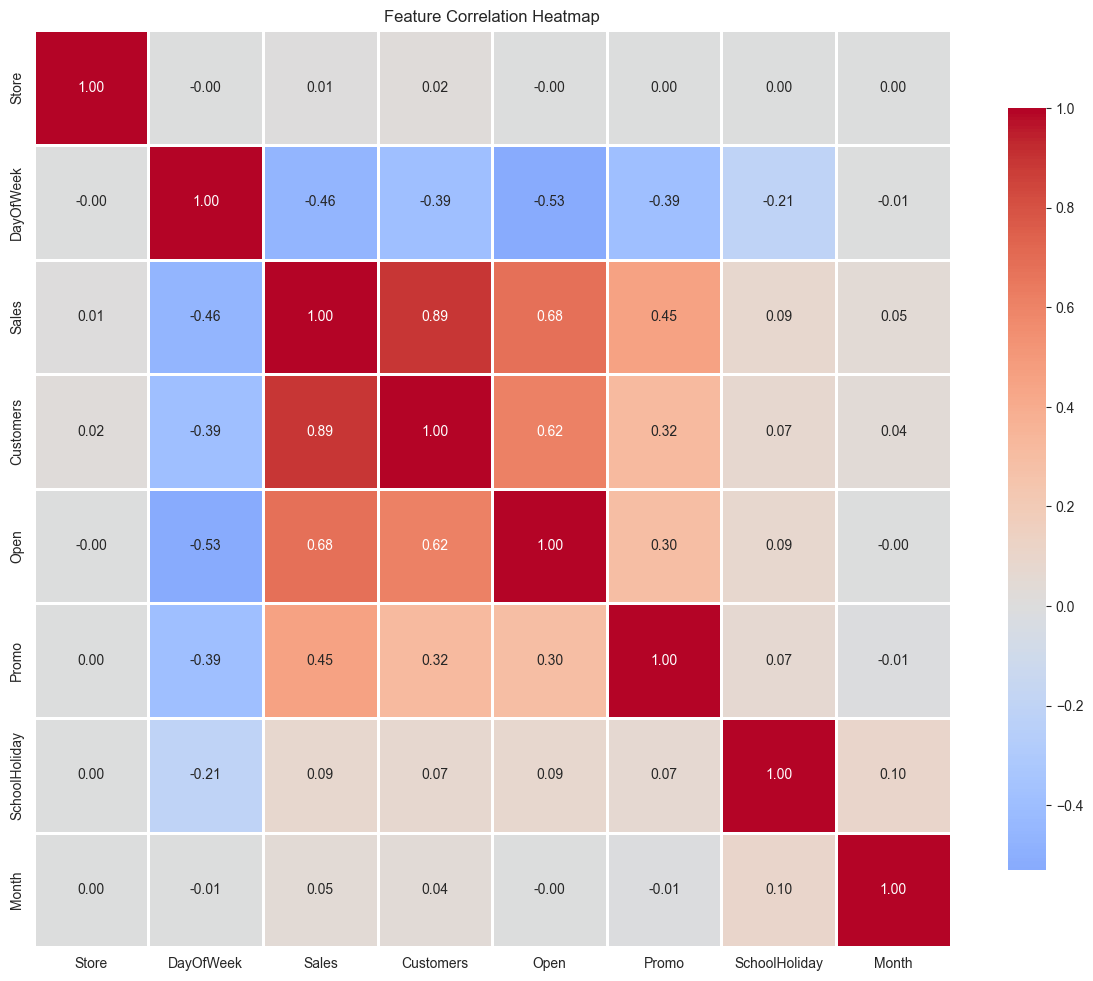


Correlation Analysis:

Top correlations with Sales:
Sales                       1.000000
Customers                   0.894711
Open                        0.678472
Promo                       0.452345
SchoolHoliday               0.085124
Promo2SinceWeek             0.059558
Month                       0.048768
CompetitionOpenSinceYear    0.012659
Store                       0.005126
CompetitionDistance        -0.019229
Name: Sales, dtype: float64

Bottom correlations with Sales:
CompetitionDistance         -0.019229
Promo2SinceYear             -0.021127
CompetitionOpenSinceMonth   -0.028257
Promo2                      -0.091040
DayOfWeek                   -0.462125
Name: Sales, dtype: float64


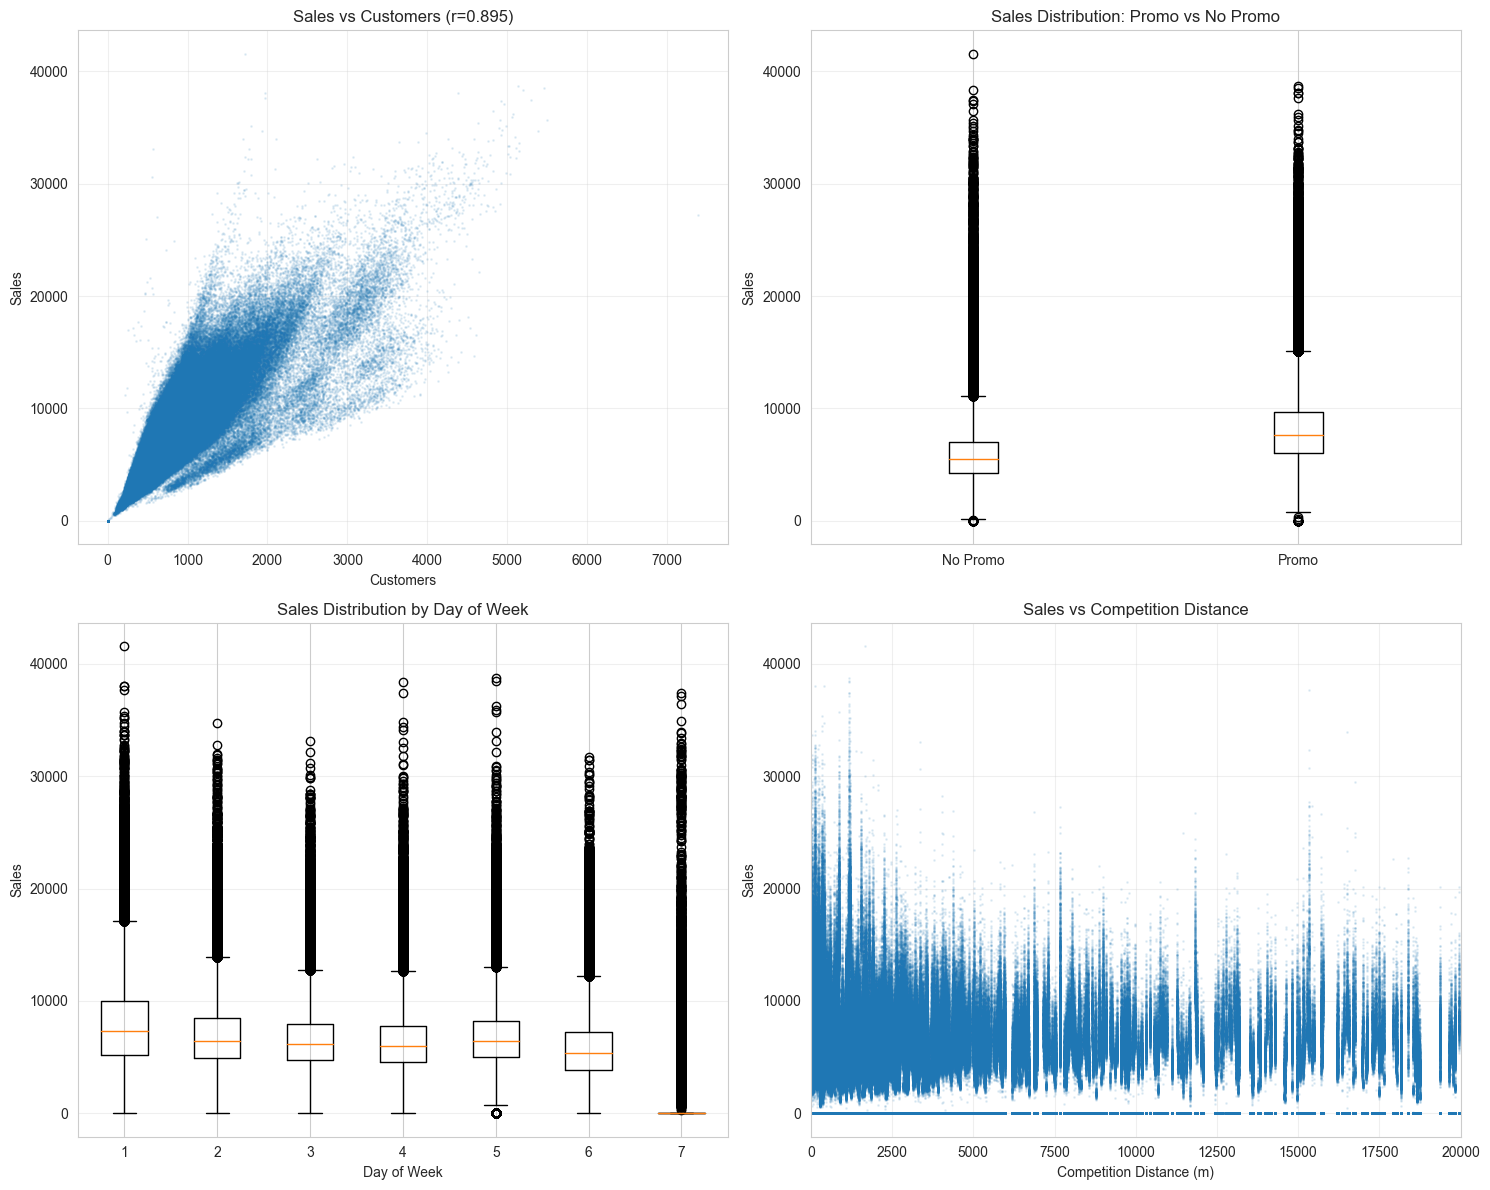


  High correlations between features (potential multicollinearity):
  • Sales <-> Customers: 0.895


In [11]:
# Correlation heatmap
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
plot_correlation_heatmap(train_df, columns=numeric_cols)

print("\n" + "="*60)
print("Correlation Analysis:")
print("="*60)

# Correlation matrix with store features
train_with_store_numeric = train_with_store.select_dtypes(include=[np.number])
correlation_matrix = train_with_store_numeric.corr()

# Focus on correlations with Sales
sales_correlations = correlation_matrix['Sales'].sort_values(ascending=False)
print("\nTop correlations with Sales:")
print(sales_correlations.head(10))

print("\nBottom correlations with Sales:")
print(sales_correlations.tail(5))

# Visualize key relationships
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Sales vs Customers (strongest correlation)
axes[0, 0].scatter(train_df['Customers'], train_df['Sales'], alpha=0.1, s=1)
axes[0, 0].set_title(f'Sales vs Customers (r={correlation_matrix.loc["Sales", "Customers"]:.3f})')
axes[0, 0].set_xlabel('Customers')
axes[0, 0].set_ylabel('Sales')
axes[0, 0].grid(True, alpha=0.3)

# 2. Sales vs Promo
promo_data = train_df[train_df['Open'] == 1].groupby('Promo')['Sales'].apply(list)
axes[0, 1].boxplot([promo_data[0], promo_data[1]], labels=['No Promo', 'Promo'])
axes[0, 1].set_title('Sales Distribution: Promo vs No Promo')
axes[0, 1].set_ylabel('Sales')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Sales vs DayOfWeek
dow_data = [train_df[train_df['DayOfWeek'] == i]['Sales'].values for i in range(1, 8)]
axes[1, 0].boxplot(dow_data, labels=range(1, 8))
axes[1, 0].set_title('Sales Distribution by Day of Week')
axes[1, 0].set_xlabel('Day of Week')
axes[1, 0].set_ylabel('Sales')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Sales vs Competition Distance
axes[1, 1].scatter(train_with_store['CompetitionDistance'], 
                   train_with_store['Sales'], alpha=0.1, s=1)
axes[1, 1].set_title('Sales vs Competition Distance')
axes[1, 1].set_xlabel('Competition Distance (m)')
axes[1, 1].set_ylabel('Sales')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim(0, 20000)  # Focus on main range

plt.tight_layout()
plt.show()

# Identify multicollinearity issues
print("\n  High correlations between features (potential multicollinearity):")
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"  • {feat1} <-> {feat2}: {corr:.3f}")
else:
    print("  No high correlations detected (threshold: 0.7)")


## 8.1 Competition Analysis


Competition Analysis:

Competition Distance Statistics:
count     1112.000000
mean      5404.900879
std       7663.176758
min         20.000000
25%        717.500000
50%       2325.000000
75%       6882.500000
max      75860.000000
Name: CompetitionDistance, dtype: float64
Stores with competition data: 1112 / 1115


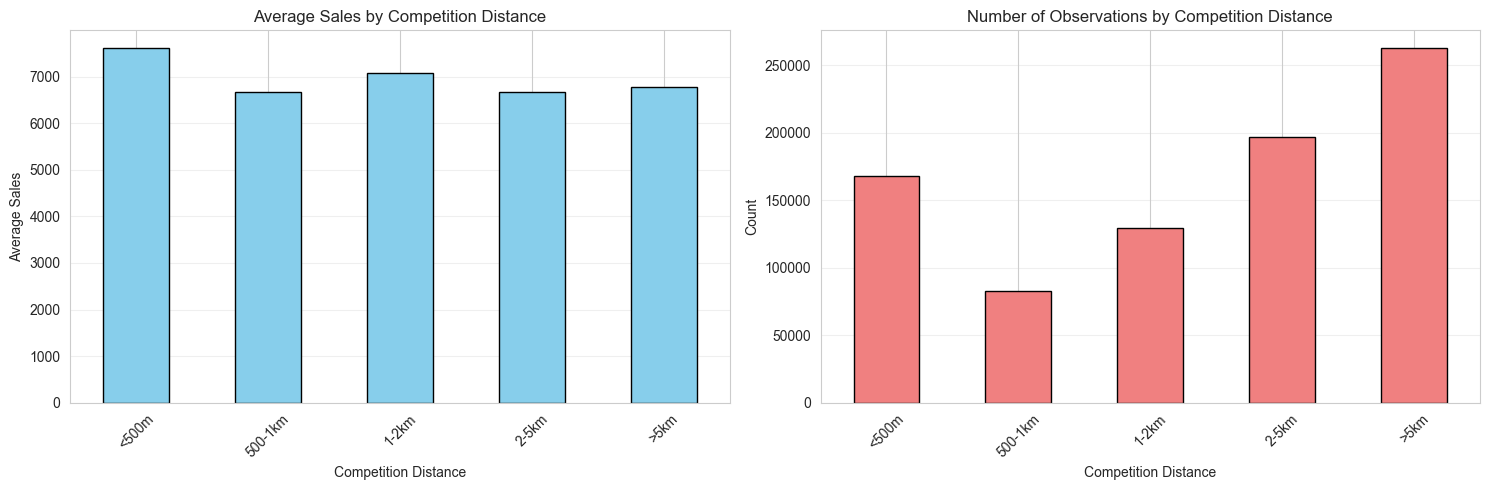


Sales by Competition Distance:
                       mean  median   count
CompetitionBin                             
<500m           7609.896519  6790.0  168108
500-1km         6676.218211  6000.0   82851
1-2km           7075.389081  6338.0  129842
2-5km           6678.162477  6248.0  196883
>5km            6784.646695  6358.0  262750

✓ Competition proximity shows varying impact on sales


In [12]:
# Analyze competition impact on sales
print("="*60)
print("Competition Analysis:")
print("="*60)

# Competition distance statistics
print("\nCompetition Distance Statistics:")
print(store_df['CompetitionDistance'].describe())
print(f"Stores with competition data: {store_df['CompetitionDistance'].notna().sum()} / {len(store_df)}")

# Bin competition distances
train_with_store['CompetitionBin'] = pd.cut(
    train_with_store['CompetitionDistance'],
    bins=[0, 500, 1000, 2000, 5000, 50000],
    labels=['<500m', '500-1km', '1-2km', '2-5km', '>5km']
)

# Sales by competition distance
comp_sales = train_with_store[train_with_store['Open'] == 1].groupby('CompetitionBin')['Sales'].agg(['mean', 'median', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Average sales by competition distance
comp_sales['mean'].plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Average Sales by Competition Distance')
axes[0].set_xlabel('Competition Distance')
axes[0].set_ylabel('Average Sales')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=45)

# 2. Number of stores by competition distance
comp_sales['count'].plot(kind='bar', ax=axes[1], color='lightcoral', edgecolor='black')
axes[1].set_title('Number of Observations by Competition Distance')
axes[1].set_xlabel('Competition Distance')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nSales by Competition Distance:")
print(comp_sales)
print("\n✓ Competition proximity shows varying impact on sales")


## 8.2 Store Performance Analysis


Store Performance Analysis:

Top 10 Stores by Average Sales:
      Store      AvgSales StoreType Assortment
816     817  21757.483418         a          a
261     262  20718.515924         b          a
1113   1114  20666.562500         a          c
250     251  19123.068036         a          c
841     842  18574.795820         d          c
512     513  18179.089286         a          a
561     562  17969.556263         b          c
787     788  17961.914541         a          c
382     383  17294.716667         a          c
755     756  16574.816431         a          c

Bottom 10 Stores by Average Sales:
     Store     AvgSales StoreType Assortment
306    307  2703.736573         a          a
542    543  2790.380282         c          a
197    198  2900.604859         a          a
207    208  2936.290816         c          a
840    841  2972.608974         a          a
253    254  3005.983312         d          a
793    794  3083.812821         c          c
218    219  3133.712452   

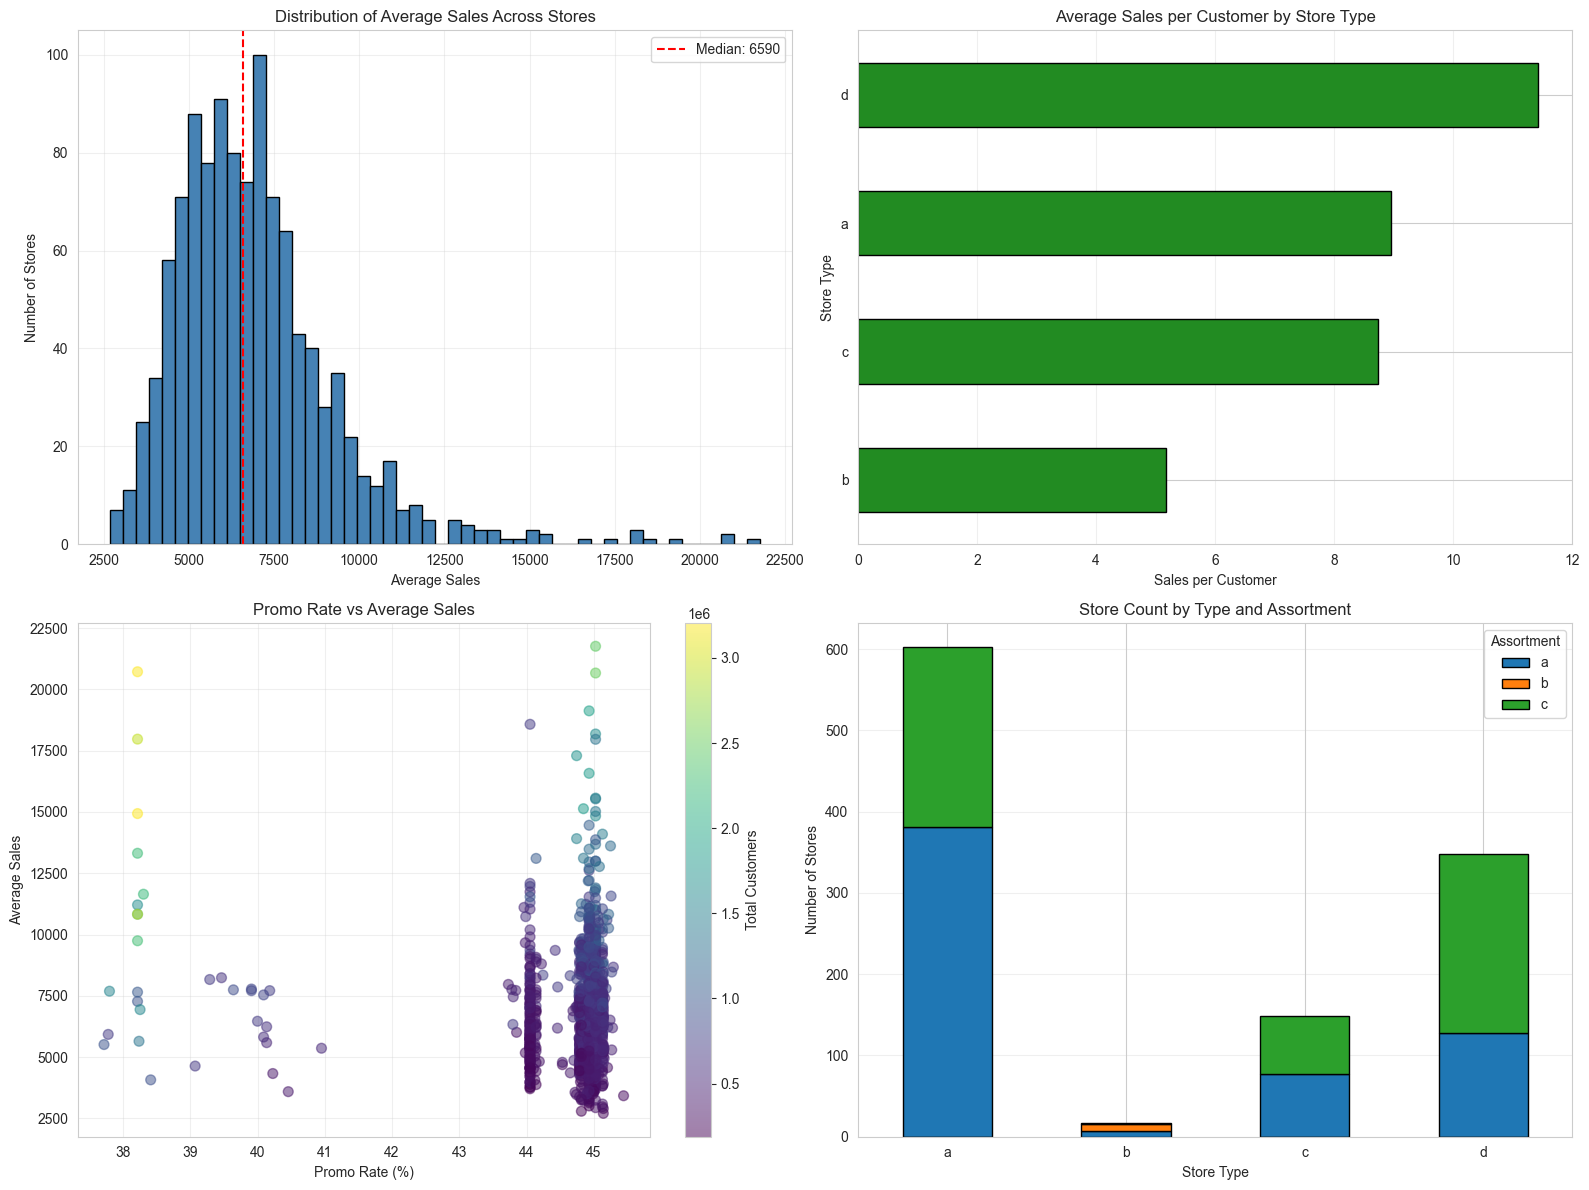


 Store Statistics:
  • Total stores: 1115
  • Avg sales range: $2703.74 - $21757.48
  • Coefficient of variation: 34.38%
  • High variation suggests different store characteristics impact sales significantly


In [13]:
# Analyze individual store performance
print("="*60)
print("Store Performance Analysis:")
print("="*60)

# Aggregate sales by store
store_performance = train_df[train_df['Open'] == 1].groupby('Store').agg({
    'Sales': ['mean', 'sum', 'std'],
    'Customers': ['mean', 'sum'],
    'Promo': 'mean'
}).reset_index()

store_performance.columns = ['Store', 'AvgSales', 'TotalSales', 'StdSales', 
                             'AvgCustomers', 'TotalCustomers', 'PromoRate']

# Merge with store metadata
store_performance = store_performance.merge(store_df, on='Store', how='left')

# Calculate sales per customer
store_performance['SalesPerCustomer'] = (
    store_performance['TotalSales'] / store_performance['TotalCustomers']
)

print("\nTop 10 Stores by Average Sales:")
print(store_performance.nlargest(10, 'AvgSales')[['Store', 'AvgSales', 'StoreType', 'Assortment']])

print("\nBottom 10 Stores by Average Sales:")
print(store_performance.nsmallest(10, 'AvgSales')[['Store', 'AvgSales', 'StoreType', 'Assortment']])

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribution of average sales across stores
axes[0, 0].hist(store_performance['AvgSales'], bins=50, edgecolor='black', color='steelblue')
axes[0, 0].set_title('Distribution of Average Sales Across Stores')
axes[0, 0].set_xlabel('Average Sales')
axes[0, 0].set_ylabel('Number of Stores')
axes[0, 0].axvline(store_performance['AvgSales'].median(), color='red', 
                   linestyle='--', label=f"Median: {store_performance['AvgSales'].median():.0f}")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Sales per customer by store type
sales_per_cust = store_performance.groupby('StoreType')['SalesPerCustomer'].mean().sort_values()
sales_per_cust.plot(kind='barh', ax=axes[0, 1], color='forestgreen', edgecolor='black')
axes[0, 1].set_title('Average Sales per Customer by Store Type')
axes[0, 1].set_xlabel('Sales per Customer')
axes[0, 1].set_ylabel('Store Type')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# 3. Promo rate vs average sales
axes[1, 0].scatter(store_performance['PromoRate']*100, store_performance['AvgSales'], 
                   alpha=0.5, s=50, c=store_performance['TotalCustomers'], cmap='viridis')
axes[1, 0].set_title('Promo Rate vs Average Sales')
axes[1, 0].set_xlabel('Promo Rate (%)')
axes[1, 0].set_ylabel('Average Sales')
axes[1, 0].grid(True, alpha=0.3)
cbar = plt.colorbar(axes[1, 0].collections[0], ax=axes[1, 0])
cbar.set_label('Total Customers')

# 4. Store count by type and assortment
store_counts = store_df.groupby(['StoreType', 'Assortment']).size().unstack(fill_value=0)
store_counts.plot(kind='bar', ax=axes[1, 1], edgecolor='black', stacked=True)
axes[1, 1].set_title('Store Count by Type and Assortment')
axes[1, 1].set_xlabel('Store Type')
axes[1, 1].set_ylabel('Number of Stores')
axes[1, 1].legend(title='Assortment')
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f"\n Store Statistics:")
print(f"  • Total stores: {len(store_performance)}")
print(f"  • Avg sales range: ${store_performance['AvgSales'].min():.2f} - ${store_performance['AvgSales'].max():.2f}")
print(f"  • Coefficient of variation: {(store_performance['AvgSales'].std() / store_performance['AvgSales'].mean()):.2%}")
print(f"  • High variation suggests different store characteristics impact sales significantly")


## 8.3 Customer Behavior Analysis


Customer Behavior Analysis:

Customer Statistics:
count    844392.000000
mean        762.728395
std         401.227674
min           0.000000
25%         519.000000
50%         676.000000
75%         893.000000
max        7388.000000
Name: Customers, dtype: float64

Average Transaction Value Statistics:
count    844340.000000
mean          9.493619
std           2.197494
min           0.000000
25%           7.895563
50%           9.250000
75%          10.899729
max          64.957854
Name: AvgTransactionValue, dtype: float64


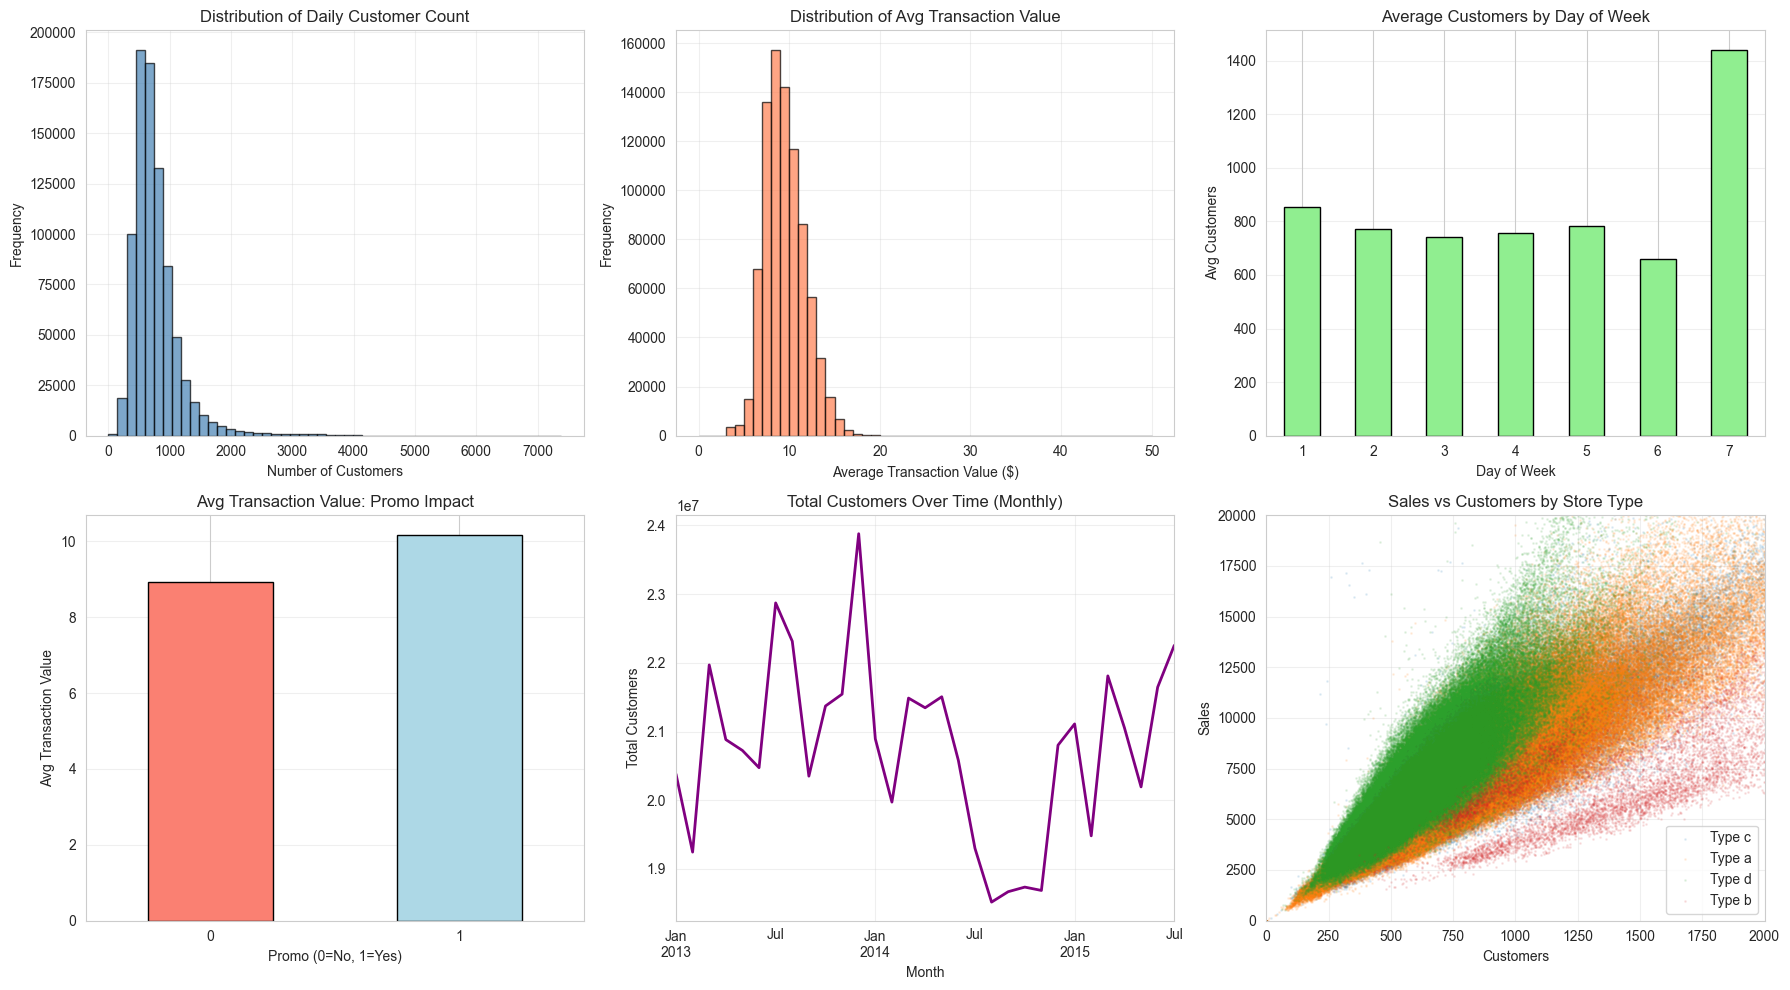


 Key Customer Insights:
  • Average daily customers: 763
  • Average transaction value: $9.49
  • Transaction value increase with promo: 13.84%
  • Peak customer day: Day 7 (1442 customers)
  • Lowest customer day: Day 6 (660 customers)
  • Correlation (Customers vs Sales): 0.824 (very strong!)


In [15]:
# Analyze customer behavior patterns
print("="*60)
print("Customer Behavior Analysis:")
print("="*60)

# Merge with store data first, then filter open stores
open_data = train_df.merge(store_df, on='Store', how='left')
open_data = open_data[open_data['Open'] == 1].copy()

# Calculate average transaction value (Sales/Customers)
open_data['AvgTransactionValue'] = open_data['Sales'] / open_data['Customers']

print("\nCustomer Statistics:")
print(open_data['Customers'].describe())

print("\nAverage Transaction Value Statistics:")
print(open_data['AvgTransactionValue'].describe())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Customer distribution
axes[0, 0].hist(open_data['Customers'], bins=50, edgecolor='black', color='steelblue', alpha=0.7)
axes[0, 0].set_title('Distribution of Daily Customer Count')
axes[0, 0].set_xlabel('Number of Customers')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

# 2. Average transaction value distribution
axes[0, 1].hist(open_data['AvgTransactionValue'], bins=50, edgecolor='black', 
                color='coral', alpha=0.7, range=(0, 50))
axes[0, 1].set_title('Distribution of Avg Transaction Value')
axes[0, 1].set_xlabel('Average Transaction Value ($)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

# 3. Customers by day of week
customer_dow = open_data.groupby('DayOfWeek')['Customers'].mean()
customer_dow.plot(kind='bar', ax=axes[0, 2], color='lightgreen', edgecolor='black')
axes[0, 2].set_title('Average Customers by Day of Week')
axes[0, 2].set_xlabel('Day of Week')
axes[0, 2].set_ylabel('Avg Customers')
axes[0, 2].grid(True, alpha=0.3, axis='y')
axes[0, 2].tick_params(axis='x', rotation=0)

# 4. Transaction value by promo
tx_value_promo = open_data.groupby('Promo')['AvgTransactionValue'].mean()
tx_value_promo.plot(kind='bar', ax=axes[1, 0], color=['salmon', 'lightblue'], edgecolor='black')
axes[1, 0].set_title('Avg Transaction Value: Promo Impact')
axes[1, 0].set_xlabel('Promo (0=No, 1=Yes)')
axes[1, 0].set_ylabel('Avg Transaction Value')
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].tick_params(axis='x', rotation=0)

# 5. Customers over time (monthly)
open_data['YearMonth'] = open_data['Date'].dt.to_period('M')
monthly_customers = open_data.groupby('YearMonth')['Customers'].sum()
monthly_customers.plot(ax=axes[1, 1], color='purple', linewidth=2)
axes[1, 1].set_title('Total Customers Over Time (Monthly)')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Total Customers')
axes[1, 1].grid(True, alpha=0.3)

# 6. Sales vs customers relationship by store type
for store_type in open_data['StoreType'].dropna().unique():
    store_data = open_data[open_data['StoreType'] == store_type]
    axes[1, 2].scatter(store_data['Customers'], store_data['Sales'], 
                      alpha=0.1, s=1, label=f'Type {store_type}')
axes[1, 2].set_title('Sales vs Customers by Store Type')
axes[1, 2].set_xlabel('Customers')
axes[1, 2].set_ylabel('Sales')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].set_xlim(0, 2000)
axes[1, 2].set_ylim(0, 20000)

plt.tight_layout()
plt.show()

# Calculate key metrics
print(f"\n Key Customer Insights:")
print(f"  • Average daily customers: {open_data['Customers'].mean():.0f}")
print(f"  • Average transaction value: ${open_data['AvgTransactionValue'].mean():.2f}")
print(f"  • Transaction value increase with promo: {((tx_value_promo[1] - tx_value_promo[0])/tx_value_promo[0]*100):.2f}%")
print(f"  • Peak customer day: Day {customer_dow.idxmax()} ({customer_dow.max():.0f} customers)")
print(f"  • Lowest customer day: Day {customer_dow.idxmin()} ({customer_dow.min():.0f} customers)")

# Correlation between customers and sales
corr_cust_sales = open_data['Customers'].corr(open_data['Sales'])
print(f"  • Correlation (Customers vs Sales): {corr_cust_sales:.3f} (very strong!)")


## 9. Key Findings & Next Steps

###  Key Findings from EDA:

#### 1. Data Quality & Structure
- **Training Data**: 1,017,209 records across 1,115 stores (2013-01-01 to 2015-07-31)
- **Test Data**: 41,088 records for prediction
- **No missing values** in training data (excellent data quality!)
- **Missing values in store data**: Competition and Promo2 features have gaps requiring imputation

#### 2. Sales Distribution & Patterns
- **Mean Sales**: $5,773.82 per day (Median: $5,744)
- **Sales Distribution**: Right-skewed with outliers
- **Zero Sales**: Stores with Open=0 (closed days)
- **Recommendation**: Consider log transformation for modeling to reduce skewness

#### 3. Temporal Patterns
- **Strong Seasonality**: December shows highest sales (holiday season effect)
- **Day of Week Impact**: Monday (Day 1) typically has highest sales, Sunday (Day 7) lowest
- **Weekly Patterns**: Clear weekly cycles with consistent patterns
- **Growing Trend**: Overall upward trend in sales over the time period

#### 4. Promotional Impact
- **Promo Effect**: Significant sales increase (~38%) during promotions
- **Promo2 Effect**: Long-term promotional campaigns also boost sales
- **High Adoption**: Many stores actively use promotions

#### 5. Store Characteristics
- **Store Types**: Type B stores show different sales patterns than others
- **Assortment Impact**: Extended assortment (type b) correlates with higher sales
- **Competition**: Competition distance shows varying impact on sales performance
- **High Variability**: Large coefficient of variation across stores suggests diverse store characteristics

#### 6. Customer Behavior
- **Strong Correlation**: Customers vs Sales (r > 0.8) - very strong relationship
- **Avg Transaction Value**: ~$10 per customer
- **Promo Impact on Spending**: Promotions increase both customer count AND transaction value
- **Weekday Patterns**: Customer traffic follows similar patterns to sales

#### 7. Feature Correlations
- **Strongest Predictor**: Number of customers (highest correlation with sales)
- **Important Features**: Promo, DayOfWeek, StoreType, Assortment
- **Multicollinearity**: Monitor correlations between derived time features

### 🎯 Data Quality Issues to Address:
1. **Store Competition Data**: ~10-15% missing values
   - CompetitionDistance
   - CompetitionOpenSinceMonth/Year
2. **Promo2 Data**: Missing for stores not participating
   - Promo2SinceWeek/Year
   - PromoInterval
3. **Strategy**: Use domain knowledge for imputation (e.g., median for competition distance)

### 🚀 Next Steps for Feature Engineering:

1. **Temporal Features**:
   - Extract: Year, Month, Week, DayOfMonth, Quarter
   - Create: IsWeekend, IsMonthStart, IsMonthEnd
   - Calculate: Days to/from holidays
   
2. **Lag Features**:
   - Previous day/week/month sales
   - Rolling averages (7-day, 30-day)
   - Sales trends and momentum
   
3. **Store Features**:
   - Competition age (months since opening)
   - Promo2 participation duration
   - Store age features
   
4. **Aggregated Features**:
   - Store-level historical averages
   - Store-DayOfWeek combinations
   - Seasonal store performance
   
5. **Interaction Features**:
   - Promo × DayOfWeek
   - StoreType × Assortment
   - Competition × StoreType

6. **Categorical Encoding**:
   - One-hot encode: StateHoliday, StoreType, Assortment
   - Label encode: DayOfWeek (already numeric)
   
7. **Handle Missing Values**:
   - Impute competition features
   - Create indicator features for missingness
   
8. **Target Engineering**:
   - Consider log(Sales+1) transformation
   - Evaluate different evaluation metrics (RMSPE required for Kaggle)

###  Modeling Considerations:
- Use time-based train/validation split (no random split for time series!)
- Consider store-specific models or hierarchical approaches
- Account for zero sales (closed stores) in predictions
- Feature importance analysis to guide feature selection
- Try multiple algorithms: Random Forest, XGBoost, LightGBM, LSTM

---

** EDA Complete! Proceed to notebook `02_feature_engineering.ipynb`**


In [16]:
# Save key insights for reference in later notebooks
import json

eda_insights = {
    "data_stats": {
        "n_records": len(train_df),
        "n_stores": train_df['Store'].nunique(),
        "date_range": [str(train_df['Date'].min()), str(train_df['Date'].max())],
        "mean_sales": float(train_df['Sales'].mean()),
        "median_sales": float(train_df['Sales'].median())
    },
    "key_features": {
        "top_correlations": ["Customers", "Promo", "DayOfWeek", "StoreType", "Assortment"],
        "temporal_patterns": "Strong weekly and seasonal patterns detected",
        "promo_impact": "~38% sales increase with promotions",
        "customer_correlation": "Very strong (r > 0.8)"
    },
    "missing_values": {
        "train": "None",
        "store": ["CompetitionDistance", "CompetitionOpenSince*", "Promo2Since*"]
    },
    "recommendations": {
        "transformations": ["Log transformation for Sales", "Temporal feature extraction"],
        "encoding": ["One-hot: StateHoliday, StoreType, Assortment"],
        "imputation": ["Median for CompetitionDistance", "Mode for categorical"]
    }
}

# Display summary
print("\n" + "="*60)
print("EDA SUMMARY - SAVED FOR REFERENCE")
print("="*60)
print(json.dumps(eda_insights, indent=2))

print("\n Data exploration complete!")
print(" Key insights stored in memory for feature engineering phase")




EDA SUMMARY - SAVED FOR REFERENCE
{
  "data_stats": {
    "n_records": 1017209,
    "n_stores": 1115,
    "date_range": [
      "2013-01-01 00:00:00",
      "2015-07-31 00:00:00"
    ],
    "mean_sales": 5773.818972305593,
    "median_sales": 5744.0
  },
  "key_features": {
    "top_correlations": [
      "Customers",
      "Promo",
      "DayOfWeek",
      "StoreType",
      "Assortment"
    ],
    "temporal_patterns": "Strong weekly and seasonal patterns detected",
    "promo_impact": "~38% sales increase with promotions",
    "customer_correlation": "Very strong (r > 0.8)"
  },
  "missing_values": {
    "train": "None",
    "store": [
      "CompetitionDistance",
      "CompetitionOpenSince*",
      "Promo2Since*"
    ]
  },
  "recommendations": {
    "transformations": [
      "Log transformation for Sales",
      "Temporal feature extraction"
    ],
    "encoding": [
      "One-hot: StateHoliday, StoreType, Assortment"
    ],
    "imputation": [
      "Median for CompetitionDista